### Robot Learning

## blackjack game with sarsa ($lamda$)

### Introduction

Please carefully read the following description of the card game *Blackjack*.

The goal of Blackjack is to draw cards such that their values sum to as close to 21 as possible, but do not exceed 21. All cards 2 through 10 are assigned their number as the respective value, face cards like Jack, Queen and King yield a value of 10 points. The aces are special; they can count as either 1 or 11, depending on what is more beneficial. When using the ace as 11 points does not cause the total value of the hand to exceed 21, the ace is called 'usable'. 

The actions are to *stick*, which means to stop drawing cards and let the dealer play, or to *hit*, which means to draw another card to add to your hand. 

The opponent is a dealer with a fixed strategy; the dealer will always hit when the dealer's sum of card values is below 17 points. At or above 17 points, the dealer immediately sticks, irrespective of the player's card sum. Note that the dealer only starts playing once the player is finished, so when the player has selected to stick.

The game starts by drawing two cards each to player and dealer from an infinite deck. The player can see the own cards, but only the first card which the dealer recieves, the other is face-down. If the player hits and exceeds 21 points, the player is considered *bust* and immediately loses the game. When the player decides to stick, the dealer will draw cards according to its strategy. If the dealer goes *bust* in the process, the player immediately wins the game. If not, the sum of the dealer's card values is compared to the sum of the player's card values. If they are equal, the game is considered a draw. If the player has a higher score, the player wins, and vice versa.

In this RL setting, the rewards are +1 for winning, -1 for losing, and 0 for drawing and all intermediate moves. The state is a 3-tuple consisting of the players current hand sum, the value of the dealer's initial open card and a boolean describing whether the player currently has a usable ace or not. The action space consists of the integer $0$, which corresponds to *stick*, and the integer $1$, which corresponds to *hit*. Note that this corresponds exactly to the scenario described in *Example 5.1; Reinforcement Learning: An Introduction; Sutton and Barto*.

To get started, please examine the following code cell, which loads the Blackjack environment from the utils file and plays an episode. The player is in this case the random agent. The environment is equivalent to the one provided in OpenAI Gym; we adapted the source code so that installing this python package is not necessary.

In [ ]:
import numpy as np
from helpers.utils import BlackjackEnv

np.random.seed(3)
# create a Blackjack environment
casino = BlackjackEnv()

# do this before each new episode
# state is 3-tuple: (player_current_sum, dealer_first_open_card, usable_ace_bool)
# if dealer_first_open_card == 1, the dealer is holding an ace!
starting_state = casino.reset()

# create flag tracking whether the episode is over
done = False

# create lists to save the trajectory and the decisions of the agent
actions, rewards, states = [], [], [starting_state]

# simulate until the episode is over
while not done:
    #in each non-terminal state the agent can either stick (0) or hit (1)
    possibleActions = casino.getAvailableActions()
    # select one of them randomly
    a = np.random.choice(possibleActions).item()
    # save the action
    actions.append(a)
    # execute the action using the step function
    # s is the new state
    # done is the flag whether the episode is over
    # the fourth output _ is a dict containing additional information on the environment
    # it is empty here, but passing it is according to convention in OpenAI Gym environments
    s, r, done, _ = casino.step(action = a)
    # save the states
    rewards.append(r)
    states.append(s)
    
print('Action Sequence:', actions)
print('Obtained Rewards:', rewards)
print('State Transitions:', states)

Action Sequence: [1, 0]
Obtained Rewards: [0.0, 1.0]
State Transitions: [(17, 9, 1), (21, 9, 1), (21, 9, 1)]


### Task 5.1)

Implement Sarsa($\lambda$) for Blackjack. Use an $\varepsilon$-greedy exploration strategy with $\varepsilon = 0.1$ and a time-varying scalar step-size of $\alpha_t = \frac{1}{N(s_t,a_t)+1}$, where $N(s, a)$ is the number of times the value of this state-action pair has been updated.

Run the algorithm with parameter values $\lambda \in \{0, 0.1, 0.2, \dots, 1\}$. Stop exploration and learning
after $100000$ episodes and plot the average return for the next $10000$ episodes against $\lambda$. 

Note that there is a loop over all state-actions pairs in the Sarsa($\lambda$) algorithm. This loop is straightforward (but also necessary) to vectorize. Do not hesitate to contact your tutors if you need help with this step. Also, the random agent scores around $-0.4$ on average, and your trained agents should be able to outperform this weak baseline.

<div style="text-align: right; font-weight:bold"> 5 Points </div>

Running Sarsa with lambda = 0.0
Running Sarsa with lambda = 0.1
Running Sarsa with lambda = 0.2
Running Sarsa with lambda = 0.3
Running Sarsa with lambda = 0.4
Running Sarsa with lambda = 0.5
Running Sarsa with lambda = 0.6
Running Sarsa with lambda = 0.7
Running Sarsa with lambda = 0.8
Running Sarsa with lambda = 0.9
Running Sarsa with lambda = 1.0


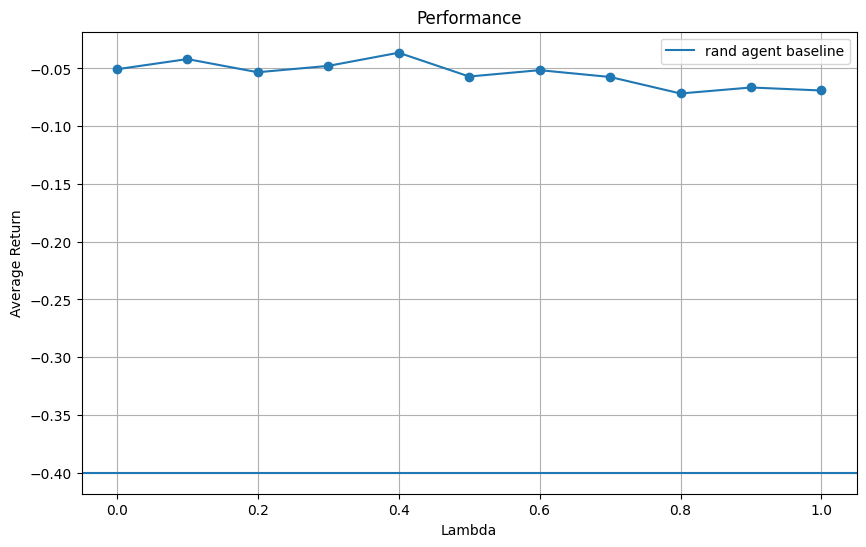

In [ ]:
import matplotlib.pyplot as plt
def epsilon_greedy_policy(Q, state, epsilon=0.1):
    player_sum, dealer_card, usable_ace = state
    usable_ace = int(usable_ace)
    # with prob of epsilon select a random action
    if np.random.rand() < epsilon:
        return np.random.choice([0, 1])
    else:
        #rlse just select the action with higest Q
        return np.argmax(Q[player_sum, dealer_card, usable_ace])

def run_sarsa_lambda(lambda_val, n_train=100000, n_eval=10000, epsilon=0.1):
    env = BlackjackEnv()
    Q = np.zeros((32, 11, 2, 2))
    N = np.zeros((32, 11, 2, 2))

    for episode in range(n_train):
        E = np.zeros((32, 11, 2, 2))
        state = env.reset()
        action = epsilon_greedy_policy(Q, state, epsilon) #choose an initial action
        done = False

        while not done:
            next_state, reward, done, _ = env.step(action)
            if done is False:
                next_action = epsilon_greedy_policy(Q, next_state, epsilon)
            else:
                next_action = None
            player_sum, dealer_card, usable_ace = state
            player_sum_n, dealer_card_n, usable_ace_n = next_state
            usable_ace = int(usable_ace)
            usable_ace_n = int(usable_ace_n)
            if done is True:
                target = reward + 0
            else:
                target = reward + Q[player_sum_n, dealer_card_n, usable_ace_n, next_action]
            # difference between target and current Q 
            delta = target - Q[player_sum, dealer_card, usable_ace, action]

            N[player_sum, dealer_card, usable_ace, action] += 1 #how many times the value has been updated
            alpha = 1.0 / N[player_sum, dealer_card, usable_ace, action] #the time-varying scalar step-size
            E[player_sum, dealer_card, usable_ace, action] += 1

            #Update Q-values for all state-action pairs
            Q += alpha * delta * E
            E *= lambda_val

            # now move to the next state and action
            state = next_state
            action = next_action

    total_return = 0
    #eval
    for _ in range(n_eval):
        state = env.reset()
        done = False
        while not done:
            action = epsilon_greedy_policy(Q, state, epsilon=0.0)  #epsilon is 0 for eval 
            state, reward, done, _ = env.step(action)
        total_return += reward

    avg_return = total_return / n_eval
    return Q,avg_return

#run for all lambdas
lambdas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
returns = []

for x in lambdas:
    print(f"Running Sarsa with lambda = {x}")
    _,avg_return = run_sarsa_lambda(lambda_val=x)
    returns.append(avg_return)

plt.figure(figsize=(10, 6))
plt.plot(lambdas, returns, marker='o')
plt.xlabel('Lambda')
plt.ylabel('Average Return')
plt.title('Performance')
plt.grid(True)
plt.axhline(-0.4, label='rand agent baseline')
plt.legend()
plt.show()


### Task 5.2)

Use your experiment from task 5.1) to select your favorite value for $\lambda$. Learn $Q$ using the Sarsa($\lambda$) algorithm for $1$ million episodes. After training, stop exploration and learning and report the average return for the next $10000$ episodes. Finally, visualize the resulting policy by using the helper function *plotPolicy(Q)*.

<div style="text-align: right; font-weight:bold"> 2 Points </div>

Final average return after training with λ = 0.4: -0.0339


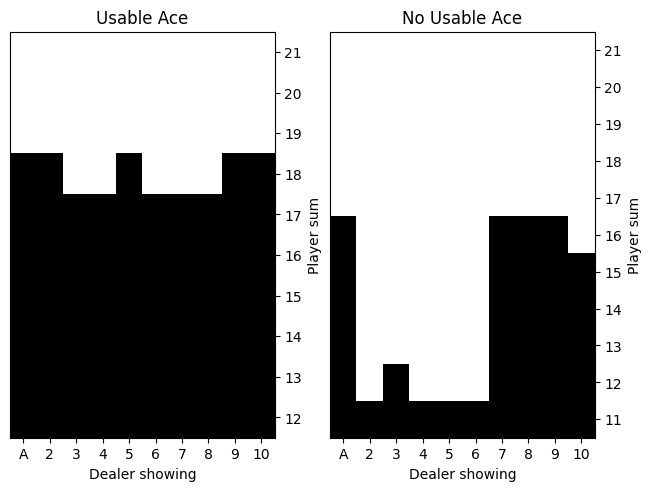

In [ ]:
from helpers.utils import plotPolicy

best_lambda = 0.4  # chose the highest lambda from what was ran
Q_final, final_avg_return = run_sarsa_lambda(lambda_val=best_lambda,n_train=1000000, n_eval=10000, epsilon=0.1)
print(f"Final average return after training with λ = {best_lambda}: {final_avg_return:.4f}")

plotPolicy(Q_final)


### Task 5.3)

Now consider a simple coarse coding value function approximator that is based on a binary feature vector $\phi_{s, a} \in \mathbb{R}^{128}$ with $8 \times 4 \times 2 \times 2 = 128$ features. Each binary feature has a value of 1 iff $(s, a)$ lies within the cuboid of state-action-space corresponding to that feature. The cuboids have the following overlapping intervals:

$player(s) = \{[4, 7], [6, 9], [8, 11], [10, 13], [12, 15], [14, 17], [18, 20], [19, 21]\}$

$dealer(s) = \{[1,4], [3, 6], [5, 8], [7, 10]\}$

$usable\_ace(s) = \{0,1\}$

$a = \{0, 1\}$

where

* player(s) is the sum of the player’s cards (4–21) in state s
* dealer(s) is the value of the dealer’s first card (1–10) in state s

Implement a function $phi(s,a)$ which takes a state-action pair $(s,a)$ and maps it to a vector $\phi_{s,a}$ as described above.

<div style="text-align: right; font-weight:bold"> 3 Points </div>

In [ ]:
def phi(state, action):
    player_sum, dealer_card, usable_ace = state
    player_intervals = [(4, 7), (6, 9), (8, 11), (10, 13), (12, 15), (14, 17), (18, 20), (19, 21)]
    dealer_intervals = [(1, 4), (3, 6), (5, 8), (7, 10)]
    usable_ace_values = [0, 1]
    actions = [0, 1]

    feature = np.zeros(128, dtype=int)

    #Loop through all combinations of intervals
    index = 0
    for i, p_range in enumerate(player_intervals):
        for j, d_range in enumerate(dealer_intervals):
            for k, ua in enumerate(usable_ace_values):
                for l, a in enumerate(actions):
                    #we see if the current (s, a)is in the current cuboid
                    if (p_range[0] <= player_sum <= p_range[1] and
                        d_range[0] <= dealer_card <= d_range[1] and
                        usable_ace == ua and
                        action == a):
                        #set the index to 1
                        feature[index] = 1
                    #we go to the next
                    index += 1

    return feature
#test
s = (11, 3, 1)
a = 1          

f = phi(s, a)
print(f"Nonzero: {np.nonzero(f)}")
print(f"Feature vector: {f}")

Nonzero indices: (array([35, 39, 51, 55], dtype=int64),)
Feature vector: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Task 5.4)

Conduct one more Sarsa($\lambda$) experiment, but this time use a linear value function approximation $Q(s,a) = \theta \cdot \phi_{s,a}$. Use a constant exploration of $\varepsilon=0.1$, a constant step-size of $\alpha=0.1$ and your favorite $\lambda$.

Stop exploration and learning after $200000$ episodes and report the average return for the next $10000$ episodes.

To clarify, $\theta$ is a row vector which your algorithm learns instead of $Q(s,a)$. The row vector times column vector product $Q(s,a) = \theta \cdot \phi_{s,a}$ can also be understood as $Q(s,a) = \sum_{i=0}^{127} \theta(i)\phi_{s,a}(i)$.

<div style="text-align: right; font-weight:bold"> 4 Points </div>

In [ ]:
def greedy_policy_new(state, theta, epsilon=0.1):
    if np.random.rand() < epsilon:
        return np.random.choice([0, 1])
    q = [np.dot(theta, phi(state, a)) for a in [0, 1]] 
    return np.argmax(q)

theta = np.zeros(128)
lambda_ = 0.5
alpha = 0.1
epsilon = 0.1
num_episodes = 200000
env = BlackjackEnv()
for episode in range(num_episodes):
    state = env.reset()
    action = greedy_policy_new(state, theta, epsilon)
    #eligibility trace vector
    z = np.zeros_like(theta)
    #initial feature vector
    phi_sa = phi(state, action)
    done = False

    while not done:
        next_state, reward, done, _ = env.step(action)

        if done is False:
            next_action = greedy_policy_new(next_state, theta, epsilon)
        else:
            next_action = None

        if done is False:
            phi_next = phi(next_state, next_action)
        else:
            phi_next = np.zeros_like(theta)

        delta = reward + np.dot(theta, phi_next) - np.dot(theta, phi_sa)
        #update eligibility trace
        z = lambda_ * z + phi_sa
        theta += alpha * delta * z

        state = next_state
        action = next_action
        phi_sa = phi_next


total_return = 0
num_eval_episodes = 10000
#for eval
for _ in range(num_eval_episodes):
    state = env.reset()
    done = False
    episode_return = 0

    while not done:
        next_action = greedy_policy_new(next_state, theta, epsilon) #no epsilon for eval
        state, reward, done, _ = env.step(action)
        episode_return += reward

    total_return += episode_return

avg_return = total_return / num_eval_episodes
print(f"avg return over 10000 evaluation episodes: {avg_return:.4f}")

avg return over 10000 evaluation episodes: -0.1868


### Task 5.5)

Implement the actor-critic version of TD(0) control. You can proceed as described on slide 7 in lecture 05. However, please adjust the update of the preferences $p(s,a)$ to

$$p[s_t][a_t] \leftarrow p[s_t][a_t] + \beta \delta_t [1 - \pi(s,a_t)]$$

This represents the learning rule for the actor. For the critic, you can update state values $V(s_t)$ according to

$$V[s_t] \leftarrow V[s_t] + $\alpha $\delta_t$$ 

after updating the actor for each step of the episode. Use $\alpha = \beta = 0.1$ and $\gamma = 0.99$ and learn for 1 million episodes. Report the mean return of the final  10000  episodes.

Then, visualize the policy induced by $p$. It is possible to use *plotPolicy($\pi$)* for this purpose.

<div style="text-align: right; font-weight:bold"> 6 Points </div>

avg return over 10,000 episodes: -0.2367


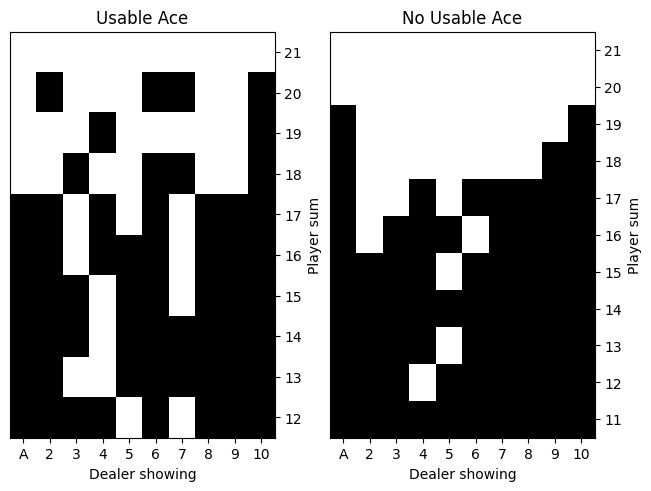

In [ ]:
import numpy as np

np.random.seed(3)

alpha = 0.1
beta = 0.1
gamma = 0.99
num_episodes = 10000

V = np.zeros((32, 11, 2))
p = np.zeros((32, 11, 2, 2))
def cal_pi(preferences):
    prefs = preferences - np.max(preferences) #subtract max to avoid overflow
    e_prefs = np.exp(prefs)
    return e_prefs / np.sum(e_prefs)

returns = []

for episode in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        player_sum, dealer_card, usable_ace = state
        #Get action probabilities, the pi basically
        pi_s = cal_pi(p[player_sum, dealer_card, int(usable_ace)])

        #I randomly chose actions based on the pi, but I'm not sure if thats correct
        action = np.random.choice([0, 1], p=pi_s)
        next_state, reward, done, _ = env.step(action)
        n_player_sum, n_dealer_card, n_usable_ace = next_state

        delta = reward + gamma * V[n_player_sum, n_dealer_card, int(n_usable_ace)] - V[player_sum, dealer_card, int(usable_ace)]

        #update the state value
        V[player_sum, dealer_card, int(usable_ace)] += alpha * delta

        #updating the actor for each step of the episode
        for a in [0, 1]:
            if a == action:
                p[player_sum, dealer_card, int(usable_ace), a] += beta * delta * (1 - pi_s[a])
            else:
                p[player_sum, dealer_card, int(usable_ace), a] -= beta * delta * pi_s[a]

        state = next_state
        total_reward += reward
    returns.append(total_reward)
mean_return = np.mean(returns)
print(f"avg return over 10,000 episodes: {mean_return:.4f}")
plotPolicy(p)